# Аналитический отчёт: Зависимость стоимости квартир от цены на нефть

## Период анализа
20 августа 2011 - 30 июня 2015

## Замечания

- До начала 2013 года цена на квадратный метр снижалась не смотря на стабильные показатели цены на нефть. 
- С сентября 2014 нефть начала стремительно дешеветь. Со $107 до $61 за баррель за три месяца. На фоне обвала видим резкий всплеск стоимости
  квадратного метра - люди стали перекладывать деньги в надёжный по их мнению актив - недвижимость.
- В Январе 2015 произошёл повторный всплеск покупательского спроса на недвижимость на фоне ослабления рубля, повышения ипотечных ставок и
  продолжающегося падения стоимости нефти.

## Итоги

  Нельзя назвать зависимость прямой. При стабильных ценах на нефть, недвижимость может как падать (11.2011 - 01.2013), так и
  расти в цене (02.2013 - 09.2014). Нефть может только косвенно влиять на стоимость недвижимости, так как от неё в значительной
  степени зависит экономика страны и реальные доходы населения.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
# Загружаю датасет

df = pd.read_csv('Sberbank_data/train.csv')

In [3]:
# Оставляю только столбцы, которые нужны мне для исследования

df = df[['id', 'timestamp', 'full_sq', 'price_doc']]
df.to_csv('train_minimal.csv', index=False)

In [4]:
# Проверяю датасет на наличие пропусков

df.shape
df.info()
df.describe()
df.isna().mean().sort_values(ascending=False).head(20)

<class 'pandas.DataFrame'>
RangeIndex: 30471 entries, 0 to 30470
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   id         30471 non-null  int64
 1   timestamp  30471 non-null  str  
 2   full_sq    30471 non-null  int64
 3   price_doc  30471 non-null  int64
dtypes: int64(3), str(1)
memory usage: 952.3 KB


id           0.0
timestamp    0.0
full_sq      0.0
price_doc    0.0
dtype: float64

In [5]:
# Проверяю размах значений

print(f"Площадь минимальная: {df['full_sq'].min()} и максимальная: {df['full_sq'].max()}")
print(f"Дата сделки минимальная: {df['timestamp'].min()} и максимальная: {df['timestamp'].max()}")
print(f"Стоимость сделки минимальная: {df['price_doc'].min()} и максимальная: {df['price_doc'].max()}")

Площадь минимальная: 0 и максимальная: 5326
Дата сделки минимальная: 2011-08-20 и максимальная: 2015-06-30
Стоимость сделки минимальная: 100000 и максимальная: 111111112


In [6]:
# Задаю функцию для отчистки данных по IQR

def remove_iqr_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask = (df[column] >= lower_bound) & (df[column] <= upper_bound)
    removed = len(df) - mask.sum()

    print(f"{column}:")
    print(f" Q1 = {Q1}, Q3 = {Q3}, IQR = {IQR}")
    print(f"  Границы: [{lower_bound:.1f}, {upper_bound:.1f}]")
    print(f"  Удалено: {removed} ({removed / len(df) * 100:.1f}%)")

    return df[mask]


# Убираю выбросы в столбце со стоимостью и площадью

df = remove_iqr_outliers(df, 'price_doc')
df = remove_iqr_outliers(df, 'full_sq')

# Добавляю столбец со стоимостью квадртного метра жилья

df['price_per_sqm'] = df['price_doc'] / df['full_sq']

price_doc:
 Q1 = 4740002.0, Q3 = 8300000.0, IQR = 3559998.0
  Границы: [-599995.0, 13639997.0]
  Удалено: 1882 (6.2%)
full_sq:
 Q1 = 38.0, Q3 = 61.0, IQR = 23.0
  Границы: [3.5, 95.5]
  Удалено: 502 (1.8%)


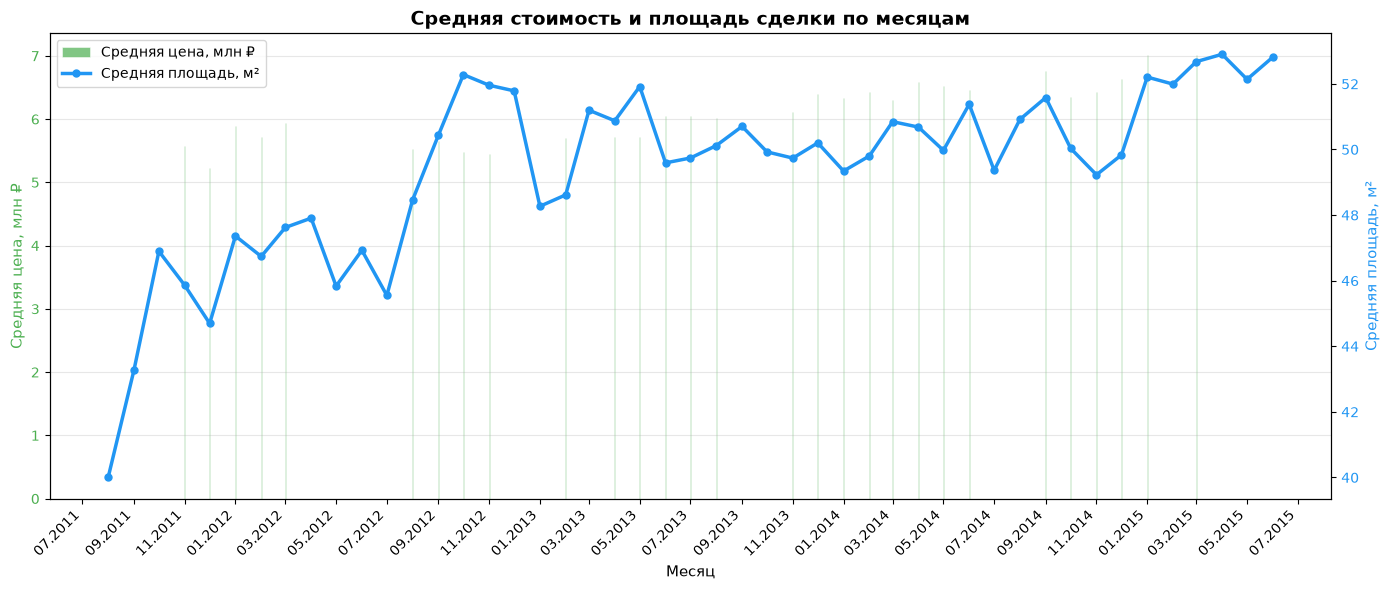

In [7]:
# Группирую данные по месяцам, строю график цены и площади

df['timestamp'] = pd.to_datetime(df['timestamp'])

monthly = df.groupby(df['timestamp'].dt.to_period('M')).agg(
    price_doc=('price_doc', 'mean'),
    full_sq=('full_sq', 'mean')
).reset_index()

monthly['timestamp'] = monthly['timestamp'].astype('datetime64[ns]')

fig,ax1 = plt.subplots(figsize=(14, 6))

bars = ax1.bar(monthly['timestamp'], monthly['price_doc'] / 1e6,
               color='#4CAF50', alpha=0.7, edgecolor='white',
               linewidth=0.5, label='Средняя цена')

ax1.set_ylabel('Средняя цена, млн ₽', fontsize=11, color='#4CAF50')
ax1.tick_params(axis='y', labelcolor='#4CAF50')
ax1.set_xlabel('Месяц', fontsize=11)

ax2 = ax1.twinx()

line = ax2.plot(monthly['timestamp'], monthly['full_sq'],
                color='#2196F3', linewidth=2.5, marker='o',
                markersize=5, label='Средняя площадь')

ax2.set_ylabel('Средняя площадь, м²', fontsize=11, color='#2196F3')
ax2.tick_params(axis='y', labelcolor='#2196F3')

ax1.set_title('Средняя стоимость и площадь сделки по месяцам',
              fontsize=14, fontweight='bold')

ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m.%Y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

ax1.grid(True, alpha=0.3, axis='y')

handles = [bars] + line
labels = ['Средняя цена, млн ₽', 'Средняя площадь, м²']
ax1.legend(handles, labels, loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('price_and_sq_by_month.png', dpi=150, bbox_inches='tight')
plt.show()

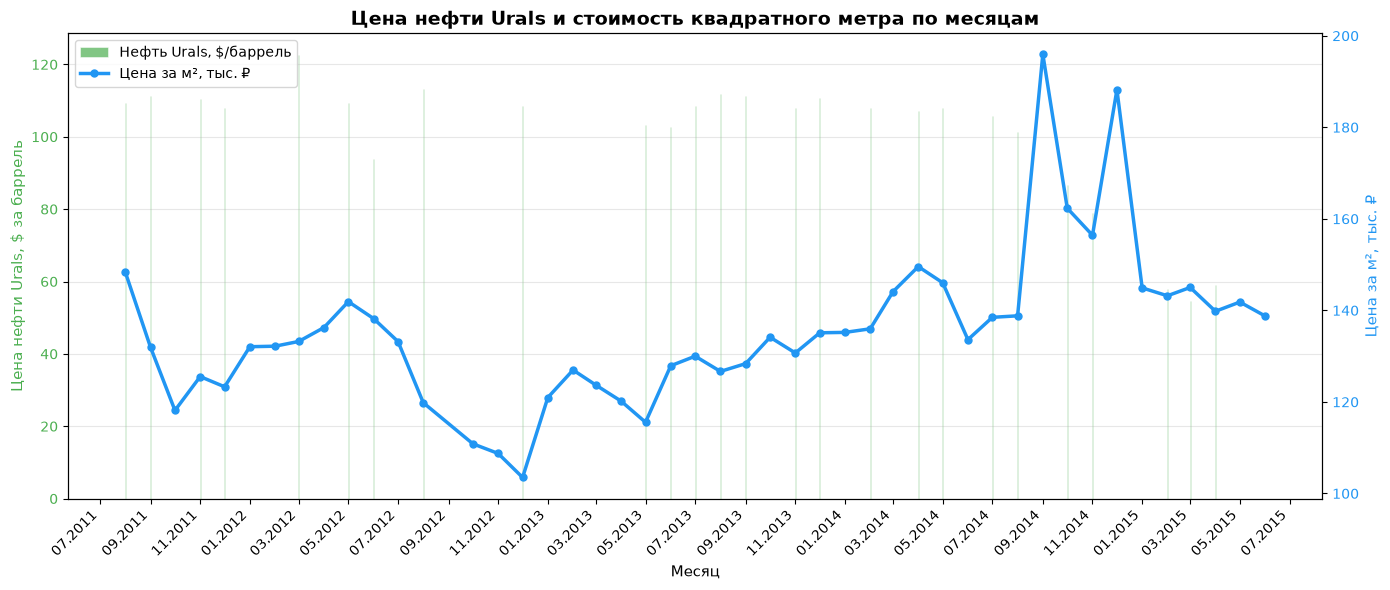

In [10]:
# Загружаю оба датасета и строю график стоимости квадртаного метра и барреля нефти

train = pd.read_csv('train_minimal.csv')
macro = pd.read_csv('Sberbank_data/macro.csv', na_values=['NA'])

train['timestamp'] = pd.to_datetime(train['timestamp'])
macro['timestamp'] = pd.to_datetime(macro['timestamp'])

train['price_per_sqm'] = train['price_doc'] / train['full_sq'].replace(0, float('nan'))

monthly_sqm = train.groupby(train['timestamp'].dt.to_period('M')).agg(
    price_per_sqm=('price_per_sqm', 'mean')
).reset_index()
monthly_sqm['timestamp'] = monthly_sqm['timestamp'].astype('datetime64[ns]')

monthly_oil = macro.groupby(macro['timestamp'].dt.to_period('M')).agg(
    oil_urals=('oil_urals', 'mean')
).reset_index()
monthly_oil['timestamp'] = monthly_oil['timestamp'].astype('datetime64[ns]')

merged = pd.merge(monthly_sqm, monthly_oil, on='timestamp', how='inner')

mask = ~(
    (merged['timestamp'].dt.year == 2012) &
    (merged['timestamp'].dt.month == 9)
)
merged = merged[mask].reset_index(drop=True)

fig, ax1 = plt.subplots(figsize=(14, 6))

bars = ax1.bar(merged['timestamp'], merged['oil_urals'],
               color='#4CAF50', alpha=0.7, edgecolor='white',
               linewidth=0.5, label='Нефть Urals')

ax1.set_ylabel('Цена нефти Urals, $ за баррель', fontsize=11, color='#4CAF50')
ax1.tick_params(axis='y', labelcolor='#4CAF50')
ax1.set_xlabel('Месяц', fontsize=11)

ax2 = ax1.twinx()
line = ax2.plot(merged['timestamp'], merged['price_per_sqm'] / 1000,
                color='#2196F3', linewidth=2.5, marker='o',
                markersize=5, label='Цена за м²')

ax2.set_ylabel('Цена за м², тыс. ₽', fontsize=11, color='#2196F3')
ax2.tick_params(axis='y', labelcolor='#2196F3')

ax1.set_title('Цена нефти Urals и стоимость квадратного метра по месяцам',
              fontsize=14, fontweight='bold')

ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m.%Y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

ax1.grid(True, alpha=0.3, axis='y')

handles = [bars] + line
labels = ['Нефть Urals, $/баррель', 'Цена за м², тыс. ₽']
ax1.legend(handles, labels, loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('oil_and_sqm_by_month.png', dpi=150, bbox_inches='tight')
plt.show()
